## Question 11 - *Do higher-priority tasks consume resources more efficiently?*

**Metrics.**
For each task, we compute average observed usage across its windows and compare with the request:
- `cpu_waste = max(0, (req_cpu - avg_cpu) / req_cpu)`
- `mem_waste = max(0, (req_mem - avg_mem) / req_mem)`

Waste near 0 means usage ≈ request (better provisioning). Waste near 1 means the task uses much less than requested (over-provisioning).

**Method.**
1. From `task_events`, extract `(job_id, task_index) -> (priority, req_cpu, req_mem)`  
   (keep max values to handle updates).
2. From `task_usage`, aggregate per task: `(avg_cpu, avg_mem)`.
3. Join requests with usage and compute waste per task.
4. Aggregate waste statistics by priority (mean waste and share of high-waste tasks).

Priority -> stats
0 {'count': 71483, 'avg_cpu_waste': 0.6085448531390988, 'avg_mem_waste': 0.8513013391066264, 'pct_cpu_waste_ge_0_5': 66.04507365387575, 'pct_mem_waste_ge_0_5': 98.7913210133878}
1 {'count': 17601, 'avg_cpu_waste': 0.4744713050499478, 'avg_mem_waste': 0.8701132200028163, 'pct_cpu_waste_ge_0_5': 47.56547923413442, 'pct_mem_waste_ge_0_5': 92.89813078802341}
2 {'count': 514, 'avg_cpu_waste': 0.5606874164543897, 'avg_mem_waste': 0.6674168631273625, 'pct_cpu_waste_ge_0_5': 51.55642023346304, 'pct_mem_waste_ge_0_5': 77.82101167315174}
4 {'count': 119730, 'avg_cpu_waste': 0.6011086788945557, 'avg_mem_waste': 0.7892683495368281, 'pct_cpu_waste_ge_0_5': 61.66457863526267, 'pct_mem_waste_ge_0_5': 95.69782009521423}
5 {'count': 1, 'avg_cpu_waste': 0.90302016, 'avg_mem_waste': 0.9429432782492185, 'pct_cpu_waste_ge_0_5': 100.0, 'pct_mem_waste_ge_0_5': 100.0}
6 {'count': 1788, 'avg_cpu_waste': 0.549471700886159, 'avg_mem_waste': 0.8970804035868174, 'pct_cpu_waste_ge_0_5': 63.5906040

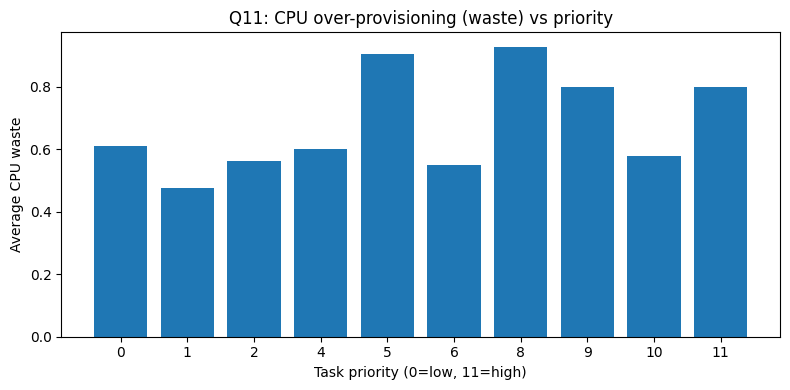

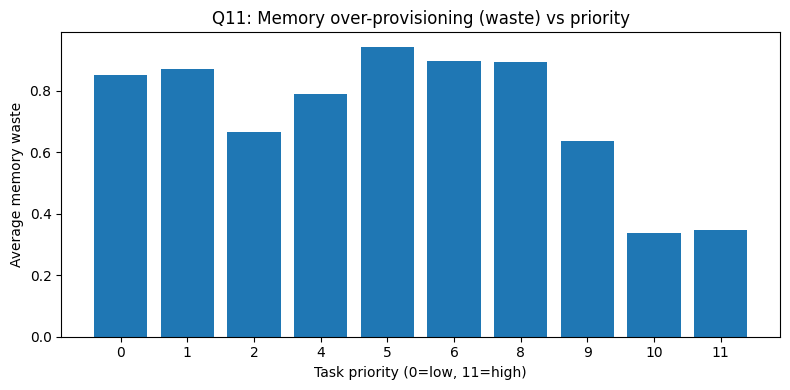

In [ ]:
import sys
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F
import time
from pyspark.storagelevel import StorageLevel
import pandas as pd

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

PATH_MACHINE_EVENTS = "./data/machine_events/*.csv.gz"
PATH_JOB_EVENTS  = "./data/job_events/*.csv.gz"
PATH_TASK_EVENTS = "./data/task_events/*.csv.gz"
PATH_TASK_USAGE = "./data/task_usage/*.csv.gz"

# ----------------------------
# Parsing utilities
# ----------------------------
def to_int(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_long(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_float(x):
    return float(x) if x not in (None, "", "NULL") else None

# task_usage indices
IDX_CPU_MEAN = 5
IDX_MEM_CANON = 6

# ----------------------------
# Parse task_events
# ----------------------------
def parse_task_event_req(line):
    p = line.split(",")
    if len(p) < 12:
        return None

    job_id = to_long(p[2])
    task_index = to_int(p[3])

    priority = to_int(p[8])
    req_cpu = to_float(p[9])
    req_mem = to_float(p[10])

    if job_id is None or task_index is None or priority is None:
        return None

    # requests can be missing; we'll keep None and handle in reducer
    return ((job_id, task_index), (priority, req_cpu, req_mem))

def reduce_req(a, b):
    pa, ca, ma = a
    pb, cb, mb = b
    p = max(pa, pb)

    def max_ignore_none(x, y):
        if x is None: return y
        if y is None: return x
        return max(x, y)

    c = max_ignore_none(ca, cb)
    m = max_ignore_none(ma, mb)
    return (p, c, m)

req_by_task = (
    sc.textFile(PATH_TASK_EVENTS)
    .map(parse_task_event_req)
    .filter(lambda x: x is not None)
    .reduceByKey(reduce_req)
    .cache()
)

# ----------------------------
# Parse task_usage
# ----------------------------
def parse_task_usage_taskavg(line):
    p = line.split(",")
    if len(p) <= max(IDX_CPU_MEAN, IDX_MEM_CANON, 3):
        return None

    job_id = to_long(p[2])
    task_index = to_int(p[3])
    cpu = to_float(p[IDX_CPU_MEAN])
    mem = to_float(p[IDX_MEM_CANON])

    if job_id is None or task_index is None:
        return None

    cpu = cpu if cpu is not None else 0.0
    mem = mem if mem is not None else 0.0

    return ((job_id, task_index), (cpu, mem, 1))

usage_agg = (
    sc.textFile(PATH_TASK_USAGE)
    .map(parse_task_usage_taskavg)
    .filter(lambda x: x is not None)
    .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2]))
    .mapValues(lambda s: (s[0]/s[2], s[1]/s[2]))  # (avg_cpu, avg_mem)
    .cache()
)

# ----------------------------
# Join requests with usage
# ----------------------------
joined = req_by_task.join(usage_agg)

def waste(req, used):
    if req is None or req <= 0:
        return None
    w = (req - used) / req
    return max(0.0, w)

per_task_metrics = (
    joined
    .map(lambda x: (
        x[1][0][0],  # priority
        (
            waste(x[1][0][1], x[1][1][0]),  # cpu_waste
            waste(x[1][0][2], x[1][1][1])   # mem_waste
        )
    ))
    .filter(lambda x: x[1][0] is not None and x[1][1] is not None)
    .cache()
)

# ----------------------------
# Aggregate by priority
# count, avg_cpu_waste, avg_mem_waste, pct_cpu_waste>=0.5, pct_mem_waste>=0.5
# ----------------------------
def seq_op(acc, w):
    n, sum_c, sum_m, hi_c, hi_m = acc
    cpu_w, mem_w = w
    n += 1
    sum_c += cpu_w
    sum_m += mem_w
    hi_c += 1 if cpu_w >= 0.5 else 0
    hi_m += 1 if mem_w >= 0.5 else 0
    return (n, sum_c, sum_m, hi_c, hi_m)

def comb_op(a, b):
    return tuple(a[i] + b[i] for i in range(5))

by_priority = (
    per_task_metrics
    .aggregateByKey((0, 0.0, 0.0, 0, 0), seq_op, comb_op)
    .mapValues(lambda s: {
        "count": s[0],
        "avg_cpu_waste": s[1]/s[0] if s[0] else 0.0,
        "avg_mem_waste": s[2]/s[0] if s[0] else 0.0,
        "pct_cpu_waste_ge_0_5": (100.0*s[3]/s[0]) if s[0] else 0.0,
        "pct_mem_waste_ge_0_5": (100.0*s[4]/s[0]) if s[0] else 0.0
    })
    .collect()
)

by_priority = sorted(by_priority, key=lambda x: x[0])

print("Priority -> stats")
for pr, st in by_priority:
    print(pr, st)

# ----------------------------
# Plot: avg waste vs priority
# ----------------------------
priorities = [pr for pr,_ in by_priority]
avg_cpu_w = [st["avg_cpu_waste"] for _,st in by_priority]
avg_mem_w = [st["avg_mem_waste"] for _,st in by_priority]

plt.figure(figsize=(8,4))
plt.bar([str(p) for p in priorities], avg_cpu_w)
plt.xlabel("Task priority (0=low, 11=high)")
plt.ylabel("Average CPU waste")
plt.title("Q11: CPU over-provisioning (waste) vs priority")
plt.tight_layout()
# plt.savefig("../figures/q11_cpu_waste_vs_priority.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,4))
plt.bar([str(p) for p in priorities], avg_mem_w)
plt.xlabel("Task priority (0=low, 11=high)")
plt.ylabel("Average memory waste")
plt.title("Q11: Memory over-provisioning (waste) vs priority")
plt.tight_layout()
# plt.savefig("../figures/q11_mem_waste_vs_priority.png", dpi=300, bbox_inches="tight")
plt.show()

**Results (subset, main groups).**
- Priority 0 (n=61,260): avg CPU waste **0.610**, avg MEM waste **0.845**
- Priority 1 (n=11,915): avg CPU waste **0.259**, avg MEM waste **0.834**
- Priority 4 (n=87,745): avg CPU waste **0.613**, avg MEM waste **0.774**
- Priority 8 (n=2,514): avg CPU waste **0.929**, avg MEM waste **0.895**
- Priority 9 (n=5,575): avg CPU waste **0.793**, avg MEM waste **0.634**
- Priorities 10–11: very small samples (n=26, n=15)

**Interpretation.**
- We do not observe a consistent “higher priority → lower waste” trend for CPU; some higher priorities show very high CPU waste (e.g., priority 8).
- Memory waste is high across most priorities, meaning over-provisioning is common (likely conservative headroom).
- The low memory waste observed for priorities 10–11 is not reliable due to very small sample sizes.